In [35]:
import pandas as pd
df = pd.read_csv('final_results_long_format.csv')

In [36]:
df

,source,question,answer,writer
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini
1,reddit_eli5,How does Nintendo 's labo work ? I just do n't...,"['In conjunction with the software , the IR se...",human_answers
2,reddit_eli5,How do they know the Chechens being hunted dow...,['The authorities in the case would have gathe...,chatgpt_answers
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers
4,reddit_eli5,"Affirmative action . Thanks , I 'm not america...","['In the US , pretty much all blacks originall...",human_answers
...,...,...,...,...
62840,finance,"When a stock price rises, does the company get...","No, when a stock price rises, the company itse...",answer_gemini
62841,open_qa,what food is in afghan,['Afghanistan has a rich and varied culinary t...,chatgpt_answers
62842,reddit_eli5,What happens if a parking ticket is lost / des...,"[""In my city you also get something by mail to...",human_answers
62843,reddit_eli5,why are companies switching advertising and lo...,"['One reason is that it \'s friendlier , under...",human_answers


In [37]:
df['answer_clean'] = (
    df['answer']
    .str.replace(r'\\n|\\r', ' ', regex=True)
    .str.replace(r'\r\n|\r|\n', ' ', regex=True)
    .str.replace(r'^\\+\s*|^\s*[\["\']+|[\]"\']+\s*$', '', regex=True)
    .str.replace(r'\s{2,}', ' ', regex=True)
)

df['answer_clean'] = df['answer_clean'].str.replace(r'^\\+\s*', '', regex=True)

In [38]:
df['answer_clean'].head(20)

0     Imagine you have a toy train. Some toy trains ...
1     In conjunction with the software , the IR sens...
2     The authorities in the case would have gathere...
3     Emulators are programs that allow a computer t...
4     In the US , pretty much all blacks originally ...
5     Imagine you have a box with a toy inside. You ...
6     The car dealership doesn't care where you get ...
7     Judging market efficiency solely from raw pric...
8     Imagine you're eating a candy. Some candies ar...
9     Martial arts can be effective in a street figh...
10    To continue your scholarships , generally . Mo...
11    Easter is a holiday that celebrates the resurr...
12    Isopropyl alcohol is a type of alcohol that ca...
13    All parties in WWII engaged in extensive bombi...
14    Hiroshima and Nagasaki are both densely popula...
15    Chemotherapy is a poison designed to kill fast...
16    Imagine you're swinging a ball on a string aro...
17    In Japanese, it is common to add certain w

In [39]:
df['answer_length'] = df['answer'].apply(lambda x: len(x.split()))
df['question_length'] = df['question'].apply(lambda x: len(x.split()))

In [40]:
df.shape

(62845, 7)

In [41]:
# Select only answers with length between 150 and 350
df_length_controlled = df[(df['answer_length'] >= 150) & (df['answer_length'] <= 350)].copy()

In [47]:
df_length_controlled.groupby('writer')['answer_length'].count()

writer
answer_gemini      12538
chatgpt_answers    13727
human_answers       8334
Name: answer_length, dtype: int64

In [42]:
df_length_controlled.shape

(34599, 7)

In [43]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2), stop_words='english')
tfidf_matrix = vectorizer.fit_transform(df_length_controlled['answer'])
tfidf_scores = tfidf_matrix.mean(axis=1)

In [44]:
df_length_controlled.head()

,source,question,answer,writer,answer_clean,answer_length,question_length
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Imagine you have a toy train. Some toy trains ...,150,23
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,Emulators are programs that allow a computer t...,160,53
5,reddit_eli5,How can observing something change the outcome...,Imagine you have a box with a toy inside. You...,answer_gemini,Imagine you have a box with a toy inside. You ...,341,49
12,reddit_eli5,Why is 70 % isoprpyl alcohol better than 99 % ...,['Isopropyl alcohol is a type of alcohol that ...,chatgpt_answers,Isopropyl alcohol is a type of alcohol that ca...,165,38
13,reddit_eli5,How come the bombing of Hiroshima was never cl...,"[""All parties in WWII engaged in extensive bom...",human_answers,All parties in WWII engaged in extensive bombi...,207,40


In [45]:
from sklearn.metrics.pairwise import cosine_similarity

question_vecs = vectorizer.fit_transform(df_length_controlled['question'])
answer_vecs = vectorizer.transform(df_length_controlled['answer'])

df_length_controlled['cosine_sim'] = [
    cosine_similarity(question_vecs[i], answer_vecs[i])[0][0]
    for i in range(len(df_length_controlled))
]

In [29]:
df_length_controlled.head()

,source,question,answer,writer,answer_clean,answer_length,question_length,cosine_sim
0,reddit_eli5,Why do some animals become trained more easily...,Imagine you have a toy train. Some toy trains...,answer_gemini,Imagine you have a toy train. Some toy trains ...,150,23,0.214605
3,reddit_eli5,How are emulators written ? I only have very b...,['Emulators are programs that allow a computer...,chatgpt_answers,Emulators are programs that allow a computer t...,160,53,0.056167
12,reddit_eli5,Why is 70 % isoprpyl alcohol better than 99 % ...,['Isopropyl alcohol is a type of alcohol that ...,chatgpt_answers,Isopropyl alcohol is a type of alcohol that ca...,165,38,0.366318
13,reddit_eli5,How come the bombing of Hiroshima was never cl...,"[""All parties in WWII engaged in extensive bom...",human_answers,All parties in WWII engaged in extensive bombi...,207,40,0.229867
14,reddit_eli5,"Why , after both being irradiated by nuclear b...",['Hiroshima and Nagasaki are both densely popu...,chatgpt_answers,Hiroshima and Nagasaki are both densely popula...,206,45,0.541277


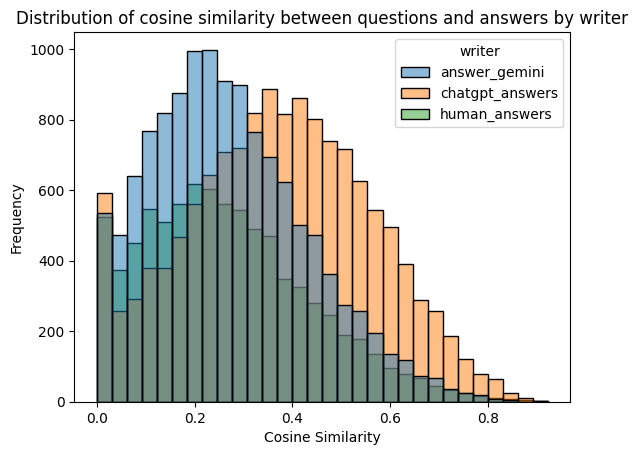

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(data = df_length_controlled, x = 'cosine_sim', hue = 'writer', bins=30)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of cosine similarity between questions and answers by writer')
plt.show()